# Basic usage of `pespace`

**The tutorial including:**
- Generating detector response in the frequency domain;
- Generating detector response in the wavelet domain;

In [1]:
import sys
sys.path.append("/home/hydrogen/workspace/Space_GW/pespace")
sys.path.append("/home/hydrogen/workspace/Space_GW/tiwave")

import taichi as ti
ti.init(arch=ti.cuda, default_fp=ti.f64, cpu_max_num_threads=1)
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

from pespace.constants import YEAR_SI

duration = YEAR_SI  # 1 year observation
cadence = 10
TDI_chans = ("A", "E", "T")
TDI_gen = "2.0"
parameters = dict(
    total_mass=3089053.9,
    mass_ratio=0.11,
    chi_1=0.3986046314480332,
    chi_2=0.5465882372512956,
    luminosity_distance=6000.42017466175677,
    inclination=0.30782038099413395,
    reference_phase=0.0,
    coalescence_time=0.0,
    ecliptic_latitude=-0.5256036732051035,
    ecliptic_longitude=1.1637,
    polarization=1.30782038099413395,
)

[Taichi] version 1.7.1, llvm 15.0.4, commit 0f143b2f, linux, python 3.10.14


[I 08/12/24 15:58:21.894 2451461] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


[Taichi] Starting on arch=cuda


/home/hydrogen/workspace/Space_GW/pespace/pespace/utils.py:7: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


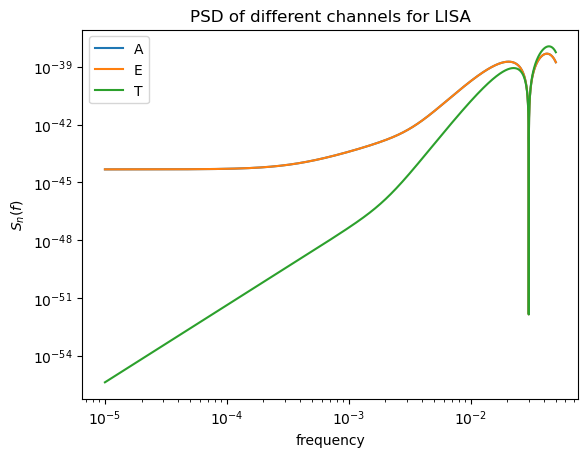

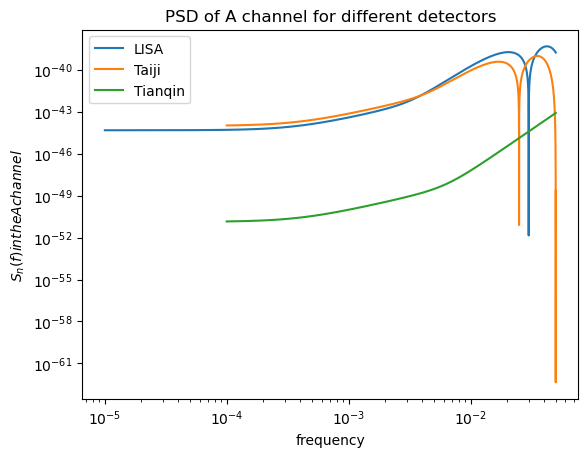

In [2]:
from pespace.detectors import TDIChannelsData, SpaceborneInterferometer
from pespace.likelihood import FrequencyDomainLikelihood
from tiwave.waveforms import IMRPhenomD

lisa_mbhb = TDIChannelsData(label="inj_MBHB_lisa", minimum_frequency=1e-5, maximum_frequency=0.1)
lisa_mbhb.set_frequency_domain_data_with_zero_value(channels=TDI_chans, generation=TDI_gen, duration=duration, cadence=cadence)
lisa_mbhb.set_frequency_domain_noise_power_density_from_model("LISA_SciRDv1")

taiji_mbhb = TDIChannelsData(label="inj_MBHB_taiji", minimum_frequency=1e-4, maximum_frequency=1)
taiji_mbhb.set_frequency_domain_data_with_zero_value(channels=TDI_chans, generation=TDI_gen, duration=duration, cadence=cadence)
taiji_mbhb.set_frequency_domain_noise_power_density_from_model("Taiji_TDC")

tianqin_mbhb = TDIChannelsData(label="inj_MBHB_tianqin", minimum_frequency=1e-4, maximum_frequency=1)
tianqin_mbhb.set_frequency_domain_data_with_zero_value(channels=TDI_chans, generation=TDI_gen, duration=duration, cadence=cadence)
tianqin_mbhb.set_frequency_domain_noise_power_density_from_model("Tianqin_Luo2016")

plt.figure()
for chan in TDI_chans:
    plt.loglog(
        lisa_mbhb.frequency_samples_numpy_array,
        lisa_mbhb.frequency_domain_noise_power_density_numpy_array[chan],
        label=chan,
    )
plt.xlabel("frequency")
plt.ylabel(r"$S_n(f)$")
plt.title("PSD of different channels for LISA")
plt.legend()

plt.figure()
plt.loglog(lisa_mbhb.frequency_samples_numpy_array, lisa_mbhb.frequency_domain_noise_power_density_numpy_array["A"], label="LISA")
plt.loglog(taiji_mbhb.frequency_samples_numpy_array, taiji_mbhb.frequency_domain_noise_power_density_numpy_array["A"], label="Taiji")
plt.loglog(tianqin_mbhb.frequency_samples_numpy_array, tianqin_mbhb.frequency_domain_noise_power_density_numpy_array["A"], label="Tianqin")
plt.xlabel("frequency")
plt.ylabel(r"$S_n(f) in the A channel$")
plt.title("PSD of A channel for different detectors")
plt.legend()


In [3]:
lisa_noise = lisa_mbhb.generate_realization_from_frequency_domain_noise_power_density()
lisa_mbhb.add_into_frequency_domian_data(lisa_noise)
lisa = SpaceborneInterferometer(name='LISA', TDI_data=lisa_mbhb, orbit="LISA_analytic")
lisa.initialize_response_container_in_frequency_domain()
wf = IMRPhenomD(lisa.TDI_data.frequency_samples)
wf.update_waveform(parameters)
lisa.update_frequency_domain_response(wf.waveform_container, parameters['ecliptic_longitude'], parameters['ecliptic_latitude'], parameters['polarization'])
lisa.inject_frequency_domain_signal(wf.waveform_container, parameters['ecliptic_longitude'], parameters['ecliptic_latitude'], parameters['polarization'])

likelihood = FrequencyDomainLikelihood(wf, lisa)
likelihood.parameters.update(parameters)
%timeit likelihood.log_likelihood()

`parameter_sanity_check` is disable, make sure all parameters passed in are valid.
`waveform_container` is not given, initializing one with returned_form=polarizations, include_tf=True


[W 08/12/24 15:58:35.524 2451461] 
Assign may lose precision: unknown <- f64
[W 08/12/24 15:58:35.557 2451461] 
Assign may lose precision: unknown <- f64
[W 08/12/24 15:58:35.590 2451461] 
Assign may lose precision: unknown <- f64
[W 08/12/24 15:58:35.626 2451461] 
Assign may lose precision: unknown <- f64
[W 08/12/24 15:58:35.661 2451461] 
Assign may lose precision: unknown <- f64
[W 08/12/24 15:58:35.695 2451461] 
Assign may lose precision: unknown <- f64
[W 08/12/24 15:58:35.728 2451461] 
Assign may lose precision: unknown <- f64
[W 08/12/24 15:58:35.762 2451461] 
Assign may lose precision: unknown <- f64
[W 08/12/24 15:58:35.866 2451461] 
Assign may lose precision: unknown <- f64
[W 08/12/24 15:58:35.933 2451461] 
Assign may lose precision: unknown <- f64
[W 08/12/24 15:58:36.005 2451461] 
Assign may lose precision: unknown <- f64
[W 08/12/24 15:58:36.039 2451461] 
Assign may lose precision: unknown <- f64
[W 08/12/24 15:58:36.107 2451461] 
Assign may lose precision: unknown <- f64

25.7 ms ± 1.31 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


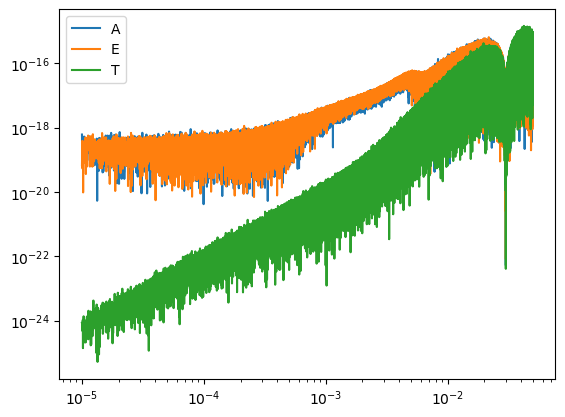

In [4]:
TDI_data_array = lisa.TDI_data.frequency_domain_TDI_data.to_numpy()
plt.figure()
for chan in TDI_chans:
    plt.loglog(
        lisa.TDI_data.frequency_samples_numpy_array,
        np.abs(TDI_data_array[chan][:, 0] + 1j * TDI_data_array[chan][:, 1]),
        label=chan,
    )
plt.legend()

## Noise power spectral density 

In [1]:
import taichi as ti
ti.init(offline_cache=False)

@ti.data_oriented
class BaseClass(object):
    @property
    def one_property(self):
        return "Property of super-class"

    @ti.kernel
    def compute(self):
        pass
    @ti.func
    def some_function(self):
        pass

class DeviatedClass(BaseClass): 
    @property
    def one_property(self):
        return "Property of sub-class"

a = DeviatedClass()
print(a.one_property)
# output: Property of super-class

[Taichi] version 1.7.1, llvm 15.0.4, commit 0f143b2f, linux, python 3.10.14


[I 08/20/24 15:53:00.503 2728696] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


[Taichi] Starting on arch=x64
Property of super-class


In [14]:
a.one_property.__class__

TypeError: DeviatedClass.one_property() missing 1 required positional argument: 'x'

In [4]:
import taichi as ti

ti.init(arch=ti.gpu)
init = ti.field(ti.i8, shape=(2, 3))

@ti.kernel
def assign_test():
    init[0, 0] = ti.cast(1, ti.i8)

assign_test()
print(init)

[Taichi] Starting on arch=cuda
[[1 0 0]
 [0 0 0]]


In [1]:
import taichi as ti

ti.init(arch=ti.gpu)
init = ti.field(ti.i8, shape=(2, 3))
init[0, 0] = 1
print(init)

[Taichi] version 1.7.1, llvm 15.0.4, commit 0f143b2f, linux, python 3.10.14


[I 08/20/24 15:43:47.334 2724385] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


[Taichi] Starting on arch=cuda
[[1 0 0]
 [0 0 0]]


[W 08/20/24 15:43:48.729 2724385] 
Assign may lose precision: unknown <- i8
